In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


# Phase 1 — Setup & data loading

In [2]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import gc
import warnings
import random
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Paths (Kaggle input directory) ──────────────────────────
PATH = '/kaggle/input/competitions/home-credit-default-risk/'

print('Loading tables...')
app_train        = pd.read_csv(PATH + 'application_train.csv')
app_test         = pd.read_csv(PATH + 'application_test.csv')
bureau           = pd.read_csv(PATH + 'bureau.csv')
bureau_balance   = pd.read_csv(PATH + 'bureau_balance.csv')
prev_app         = pd.read_csv(PATH + 'previous_application.csv')
pos_cash         = pd.read_csv(PATH + 'POS_CASH_balance.csv')
installments     = pd.read_csv(PATH + 'installments_payments.csv')
credit_card      = pd.read_csv(PATH + 'credit_card_balance.csv')

print('\n── Shapes ──────────────────────────────────────────────')
for name, df in [('app_train', app_train), ('app_test', app_test),
                 ('bureau', bureau), ('bureau_balance', bureau_balance),
                 ('prev_app', prev_app), ('pos_cash', pos_cash),
                 ('installments', installments), ('credit_card', credit_card)]:
    print(f'  {name:<20} {str(df.shape)}')

print('\n── Target distribution ──────────────────────────────────')
print(app_train['TARGET'].value_counts(normalize=True).round(4))

Loading tables...

── Shapes ──────────────────────────────────────────────
  app_train            (307511, 122)
  app_test             (48744, 121)
  bureau               (1716428, 17)
  bureau_balance       (27299925, 3)
  prev_app             (1670214, 37)
  pos_cash             (10001358, 8)
  installments         (13605401, 8)
  credit_card          (3840312, 23)

── Target distribution ──────────────────────────────────
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


# Phase 2 — Application EDA & preprocessing

In [3]:
def preprocess_application(df):
    """
    All preprocessing applied identically to train and test.
    Must be a function so we never accidentally do something to
    train that we forget to do to test.
    """
    df = df.copy()

    # ── Fix the famous DAYS_EMPLOYED sentinel ────────────────
    # 365243 means 'unemployed' — not a real duration
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # ── Readable age feature ─────────────────────────────────
    df['AGE_YEARS']             = -df['DAYS_BIRTH'] / 365
    df['EMPLOYED_YEARS']        = -df['DAYS_EMPLOYED'] / 365

    # ── Core ratio features (loan math) ──────────────────────
    # Debt-to-income: how large is this loan relative to income?
    df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'].clip(1)
    # Monthly payment burden: what fraction of monthly income is the payment?
    df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] / 12).clip(1)
    # Credit relative to goods price: how much is financed vs price?
    df['CREDIT_GOODS_RATIO']    = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE'].clip(1)
    # Annuity relative to credit: higher = shorter loan term
    df['ANNUITY_CREDIT_RATIO']  = df['AMT_ANNUITY'] / df['AMT_CREDIT'].clip(1)
    # Income per family member
    df['INCOME_PER_PERSON']     = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].clip(1)

    # ── EXT_SOURCE composite ─────────────────────────────────
    # These are the 3 strongest individual features — combine them
    df['EXT_SOURCE_MEAN']       = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCE_MIN']        = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)
    df['EXT_SOURCE_2_3']        = df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    df['EXT_SOURCE_PROD']       = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

    # ── Document flags — collapse 21 columns into a count ────
    doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
    df['DOCS_PROVIDED'] = df[doc_cols].sum(axis=1)

    # ── Social circle — normalize by total observations ──────
    df['DEF_30_RATE'] = df['DEF_30_CNT_SOCIAL_CIRCLE'] / df['OBS_30_CNT_SOCIAL_CIRCLE'].clip(1)
    df['DEF_60_RATE'] = df['DEF_60_CNT_SOCIAL_CIRCLE'] / df['OBS_60_CNT_SOCIAL_CIRCLE'].clip(1)

    # ── Phone change recency ──────────────────────────────────
    df['DAYS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].replace(0, np.nan)

    # ── Encode categoricals ──────────────────────────────────
    # # LabelEncode binary categoricals (Y/N, M/F)
    # for col in df.select_dtypes('object').columns:
    #     if df[col].nunique() == 2:
    #         le = LabelEncoder()
    #         df[col] = le.fit_transform(df[col].astype(str))
    #     else:
    #         # One-hot for low-cardinality, drop for high-cardinality
    #         if df[col].nunique() <= 10:
    #             df = pd.get_dummies(df, columns=[col], prefix=col, dummy_na=False)
    #         else:
    #             # High-cardinality (ORGANIZATION_TYPE with 58 cats):
    #             # map to TARGET mean rate (target encoding — only fit on train)
    #             # For simplicity here we drop — you can improve with target encoding
    #             df = df.drop(columns=[col])
    #############################################################
    HIGH_CARD_COLS = ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE']
                  # 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
                  # 'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS',
                  # 'WEEKDAY_APPR_PROCESS_START']

    for col in df.select_dtypes('object').columns:
        # LabelEncode binary categoricals (Y/N, M/F)
        if df[col].nunique() == 2:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

        # Target Encoding for high-cardinality
        elif col in HIGH_CARD_COLS:
            df[col] = df[col].fillna('Unknown').astype(str)
    
        # One-hot for low-cardinality
        elif df[col].nunique() <= 10:
            df = pd.get_dummies(df, columns=[col], prefix=col, dummy_na=False)
    
        else:
            # Safety net — drop anything high-cardinality not explicitly handled
            df = df.drop(columns=[col])
                    
    return df

app_train_proc = preprocess_application(app_train)
app_test_proc  = preprocess_application(app_test)

# Align columns: test may be missing dummies that appear in train
app_train_proc, app_test_proc = app_train_proc.align(
    app_test_proc, join='left', axis=1, fill_value=0
)
# Remove TARGET from test (align added it as 0s)
app_test_proc = app_test_proc.drop(columns=['TARGET'], errors='ignore')

print(f'application_train after preprocessing: {app_train_proc.shape}')
print(f'application_test  after preprocessing: {app_test_proc.shape}')

application_train after preprocessing: (307511, 182)
application_test  after preprocessing: (48744, 181)


In [ ]:
# # Free memory — large tables no longer needed
# del app_train, app_test
# gc.collect()
# print('Memory freed.')

# Phase 3 — Bureau + bureau_balance features

In [4]:
def build_bureau_features(bureau, bureau_balance):
    """
    Returns one row per SK_ID_CURR with all bureau + bureau_balance features.
    Prefix: 'buro_'
    """
    # ── Bureau_balance: Step 1 — aggregate to loan level ─────
    STATUS_MAP = {'0':0, '1':1, '2':2, '3':3, '4':4, '5':5, 'C':-1, 'X':np.nan}
    bb = bureau_balance.copy()
    bb['STATUS_NUM'] = bb['STATUS'].map(STATUS_MAP)

    bb_loan = bb.groupby('SK_ID_BUREAU').agg(
        bb_months_count    = ('MONTHS_BALANCE', 'count'),
        bb_months_min      = ('MONTHS_BALANCE', 'min'),
        bb_dpd_count       = ('STATUS', lambda x: x.isin(['1','2','3','4','5']).sum()),
        bb_status_C_count  = ('STATUS', lambda x: (x=='C').sum()),
        bb_status_num_max  = ('STATUS_NUM', 'max'),
        bb_status_num_mean = ('STATUS_NUM', 'mean'),
    )

    # Recent 12 months
    bb_recent = bb[bb['MONTHS_BALANCE'] >= -12]
    bb_recent_loan = bb_recent.groupby('SK_ID_BUREAU').agg(
        bb_recent_dpd_count = ('STATUS', lambda x: x.isin(['1','2','3','4','5']).sum()),
        bb_recent_worst     = ('STATUS_NUM', 'max'),
    )
    bb_loan = bb_loan.join(bb_recent_loan, how='left')

    # Delinquency rate (normalised by loan length)
    bb_loan['bb_dpd_rate'] = bb_loan['bb_dpd_count'] / bb_loan['bb_months_count'].clip(1)

    # ── Bureau: merge balance info, then aggregate to client ─
    buro = bureau.copy()
    buro = buro.merge(bb_loan, on='SK_ID_BUREAU', how='left')

    # ── Active vs closed subsets ──────────────────────────────
    buro_active = buro[buro['CREDIT_ACTIVE'] == 'Active']
    buro_closed = buro[buro['CREDIT_ACTIVE'] == 'Closed']

    agg = buro.groupby('SK_ID_CURR').agg(
        # Volume
        loan_count        = ('SK_ID_BUREAU',          'count'),
        active_count      = ('CREDIT_ACTIVE',         lambda x: (x=='Active').sum()),
        closed_count      = ('CREDIT_ACTIVE',         lambda x: (x=='Closed').sum()),
        prolonged_sum     = ('CNT_CREDIT_PROLONG',    'sum'),

        # Amounts
        credit_sum_mean   = ('AMT_CREDIT_SUM',        'mean'),
        credit_sum_max    = ('AMT_CREDIT_SUM',        'max'),
        debt_sum          = ('AMT_CREDIT_SUM_DEBT',   'sum'),
        overdue_sum       = ('AMT_CREDIT_SUM_OVERDUE','sum'),
        overdue_max       = ('AMT_CREDIT_SUM_OVERDUE','max'),

        # Delinquency
        dpd_max           = ('CREDIT_DAY_OVERDUE',    'max'),
        ever_overdue      = ('CREDIT_DAY_OVERDUE',    lambda x: int((x > 0).any())),

        # Time / recency
        days_credit_max   = ('DAYS_CREDIT',           'max'),
        days_credit_mean  = ('DAYS_CREDIT',           'mean'),

        # Bureau_balance rollup
        worst_status      = ('bb_status_num_max',     'max'),
        dpd_total         = ('bb_dpd_count',          'sum'),
        dpd_rate_mean     = ('bb_dpd_rate',           'mean'),
        months_total      = ('bb_months_count',       'sum'),
        recent_dpd_sum    = ('bb_recent_dpd_count',   'sum'),
        recent_worst      = ('bb_recent_worst',       'max'),
    )

    # Active-only aggregations (debt burden right now)
    agg_active = buro_active.groupby('SK_ID_CURR').agg(
        active_credit_mean  = ('AMT_CREDIT_SUM',      'mean'),
        active_debt_sum     = ('AMT_CREDIT_SUM_DEBT', 'sum'),
        active_overdue_max  = ('AMT_CREDIT_SUM_OVERDUE','max'),
    )
    agg = agg.join(agg_active, how='left')

    # Ratio features
    agg['active_ratio']    = agg['active_count'] / agg['loan_count'].clip(1)
    agg['overdue_ratio']   = (agg['overdue_sum'] > 0).astype(int)
    agg['debt_ratio']      = agg['debt_sum'] / agg['credit_sum_mean'].clip(1)

    # Trajectory: is recent behavior worse than historical?
    agg['recent_vs_overall'] = agg['recent_worst'] - agg['worst_status']

    print(f'Bureau features: {agg.shape[1]} columns for {agg.shape[0]} clients')

    ###################################################################
    # -------- Free memory: large tables no longer needed -------------
    del bb, bb_recent, bb_recent_loan, bb_loan, buro_active, buro_closed, agg_active
    gc.collect()
    print('Memory freed.')
    ##################################################################
    
    return agg.add_prefix('buro_').rename_axis('SK_ID_CURR').reset_index()

bureau_feats = build_bureau_features(bureau, bureau_balance)

# Merge
app_train_proc = app_train_proc.merge(bureau_feats, on='SK_ID_CURR', how='left')
app_test_proc  = app_test_proc.merge(bureau_feats,  on='SK_ID_CURR', how='left')

print('After bureau merge:', app_train_proc.shape)
# oof_buro, test_buro, imp_buro = run_lgbm_cv(app_train_proc, app_test_proc)

# Free memory — large tables no longer needed
del bureau, bureau_balance, bureau_feats
gc.collect()
print('Phase 3 Memory freed.')

Bureau features: 26 columns for 305811 clients
Memory freed.
After bureau merge: (307511, 208)
Phase 4 Memory freed.


# Phase 4 — Previous application features

In [ ]:
def build_prev_app_features(prev_app):
    """
    Returns one row per SK_ID_CURR with previous_application features.
    Prefix: 'prev_'
    """
    prev = prev_app.copy()

    # ── Fix 365243 sentinels ──────────────────────────────────
    days_cols = ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE',
                 'DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']
    prev[days_cols] = prev[days_cols].replace(365243, np.nan)

    approved = prev[prev['NAME_CONTRACT_STATUS'] == 'Approved']
    refused  = prev[prev['NAME_CONTRACT_STATUS'] == 'Refused']

    # ── Count and decision features ───────────────────────────
    agg = prev.groupby('SK_ID_CURR').agg(
        app_count         = ('SK_ID_PREV',            'count'),
        approved_count    = ('NAME_CONTRACT_STATUS',  lambda x: (x=='Approved').sum()),
        refused_count     = ('NAME_CONTRACT_STATUS',  lambda x: (x=='Refused').sum()),
        canceled_count    = ('NAME_CONTRACT_STATUS',  lambda x: (x=='Canceled').sum()),
        unused_count      = ('NAME_CONTRACT_STATUS',  lambda x: (x=='Unused offer').sum()),
        ever_refused_HC   = ('CODE_REJECT_REASON',    lambda x: int((x=='HC').any())),
        ever_refused_SCOFR= ('CODE_REJECT_REASON',    lambda x: int((x=='SCOFR').any())),
    )

    # ── Approved-only amount features ─────────────────────────
    agg_approved = approved.groupby('SK_ID_CURR').agg(
        credit_mean       = ('AMT_CREDIT',      'mean'),
        credit_max        = ('AMT_CREDIT',      'max'),
        annuity_mean      = ('AMT_ANNUITY',     'mean'),
        application_mean  = ('AMT_APPLICATION', 'mean'),
        term_mean         = ('CNT_PAYMENT',     'mean'),
        insured_rate      = ('NFLAG_INSURED_ON_APPROVAL','mean'),
    )
    # Approval ratio: how much was granted vs requested?
    agg_approved['approval_ratio'] = (
        approved.groupby('SK_ID_CURR').apply(
            lambda g: (g['AMT_CREDIT'] / g['AMT_APPLICATION'].clip(1)).mean()
        )
    )
    agg = agg.join(agg_approved, how='left')

    # ── Time / recency features ───────────────────────────────
    agg_time = prev.groupby('SK_ID_CURR').agg(
        days_decision_max  = ('DAYS_DECISION', 'max'),
        days_decision_mean = ('DAYS_DECISION', 'mean'),
    )
    agg = agg.join(agg_time, how='left')

    # ── Engineered ratios ─────────────────────────────────────
    agg['refusal_rate']       = agg['refused_count'] / agg['app_count'].clip(1)
    agg['days_since_last_app']= -agg['days_decision_max']

    # Most recent application status
    most_recent = prev.sort_values('DAYS_DECISION').groupby('SK_ID_CURR').last()
    agg['last_was_refused'] = (
        most_recent['NAME_CONTRACT_STATUS'] == 'Refused'
    ).astype(int)

    # Credit ask growth: last application amount / first application amount
    prev_sorted = prev.sort_values(['SK_ID_CURR','DAYS_DECISION'])
    first_last = prev_sorted.groupby('SK_ID_CURR')['AMT_APPLICATION'].agg(
        first_application='first',
        last_application='last'
    )
    first_last['credit_ask_growth'] = (
        first_last['last_application'] /
        first_last['first_application'].clip(1)
    )
    agg = agg.join(first_last[['credit_ask_growth']], how='left')

    
    print(f'Previous application features: {agg.shape[1]} columns')

    ###################################################################
    # Free memory — large tables no longer needed
    del prev, approved, refused, agg_approved, agg_time, prev_sorted, first_last, most_recent
    gc.collect()
    print('Memory freed.')
    ##################################################################
    
    return agg.add_prefix('prev_').rename_axis('SK_ID_CURR').reset_index()

prev_feats = build_prev_app_features(prev_app)

app_train_proc = app_train_proc.merge(prev_feats, on='SK_ID_CURR', how='left')
app_test_proc  = app_test_proc.merge(prev_feats,  on='SK_ID_CURR', how='left')

print('After prev_app merge:', app_train_proc.shape)
# oof_prev, test_prev, imp_prev = run_lgbm_cv(app_train_proc, app_test_proc)

del prev_feats
gc.collect()
print('Phase 4 outer memory freed.')

Previous application features: 20 columns
Memory freed.
After prev_app merge: (307511, 228)
Phase 4 outer memory freed.


# Phase 5 — POS_CASH_balance features

In [6]:
def build_pos_features(pos_cash, prev_app):
    """
    Two-hop: SK_ID_PREV → SK_ID_CURR via previous_application.
    Returns one row per SK_ID_CURR. Prefix: 'pos_'
    """
    pos = pos_cash.copy()

    # Exclude Signed rows from DPD aggregations
    # (no payment has been due yet — DPD=0 is not a reliability signal)
    pos_active = pos[pos['NAME_CONTRACT_STATUS'].isin(['Active','Completed','Demand'])]

    # ── Step 1: aggregate to loan level (SK_ID_PREV) ──────────
    pos_loan = pos.groupby('SK_ID_PREV').agg(
        pos_months_count      = ('MONTHS_BALANCE',        'count'),
        pos_instalment_total  = ('CNT_INSTALMENT',        'max'),
        pos_instalment_future = ('CNT_INSTALMENT_FUTURE', 'min'),   # min = last snapshot
        pos_ever_demand       = ('NAME_CONTRACT_STATUS',  lambda x: int((x=='Demand').any())),
        pos_completed         = ('NAME_CONTRACT_STATUS',  lambda x: int((x=='Completed').any())),
    )

    pos_loan_dpd = pos_active.groupby('SK_ID_PREV').agg(
        pos_dpd_max           = ('SK_DPD',  'max'),
        pos_dpd_mean          = ('SK_DPD',  'mean'),
        pos_late_count        = ('SK_DPD',  lambda x: (x > 0).sum()),
        pos_dpd_def_max       = ('SK_DPD_DEF', 'max'),
    )
    pos_loan = pos_loan.join(pos_loan_dpd, how='left')

    # Recency window
    pos_recent = pos_active[pos_active['MONTHS_BALANCE'] >= -12]
    pos_recent_loan = pos_recent.groupby('SK_ID_PREV').agg(
        pos_recent_dpd_max    = ('SK_DPD', 'max'),
        pos_recent_late_count = ('SK_DPD', lambda x: (x > 0).sum()),
        pos_recent_demand     = ('NAME_CONTRACT_STATUS', lambda x: int((x=='Demand').any())),
    )
    pos_loan = pos_loan.join(pos_recent_loan, how='left')

    # Ratio features
    pos_loan['pos_completion_ratio'] = (
        1 - pos_loan['pos_instalment_future'] / pos_loan['pos_instalment_total'].clip(1)
    )
    pos_loan['pos_late_rate'] = (
        pos_loan['pos_late_count'] / pos_loan['pos_months_count'].clip(1)
    )

    # ── Step 2: two-hop to applicant level ────────────────────
    prev_ids = prev_app[['SK_ID_PREV','SK_ID_CURR']]
    pos_with_curr = prev_ids.merge(pos_loan.reset_index(), on='SK_ID_PREV', how='left')

    pos_agg = pos_with_curr.groupby('SK_ID_CURR').agg(
        pos_loan_count        = ('SK_ID_PREV',           'count'),
        pos_dpd_max           = ('pos_dpd_max',          'max'),
        pos_dpd_mean          = ('pos_dpd_mean',         'mean'),
        pos_late_rate_mean    = ('pos_late_rate',        'mean'),
        pos_ever_demand       = ('pos_ever_demand',      'max'),
        pos_completed_count   = ('pos_completed',        'sum'),
        pos_completion_mean   = ('pos_completion_ratio', 'mean'),
        pos_recent_dpd_max    = ('pos_recent_dpd_max',   'max'),
        pos_recent_demand     = ('pos_recent_demand',    'max'),
    ).add_prefix('pos_').rename_axis('SK_ID_CURR')

    # Remove double prefix from add_prefix
    pos_agg.columns = [c.replace('pos_pos_','pos_') for c in pos_agg.columns]

    print(f'POS_CASH features: {pos_agg.shape[1]} columns')

    ###################################################################
    # Free memory — large tables no longer needed
    del pos, pos_active, pos_loan, pos_loan_dpd, pos_recent, pos_recent_loan, prev_ids, pos_with_curr
    gc.collect()
    print('Memory freed.')
    ##################################################################
    
    return pos_agg.reset_index()

pos_feats = build_pos_features(pos_cash, prev_app)

app_train_proc = app_train_proc.merge(pos_feats, on='SK_ID_CURR', how='left')
app_test_proc  = app_test_proc.merge(pos_feats,  on='SK_ID_CURR', how='left')

print('After POS_CASH merge:', app_train_proc.shape)
# oof_pos, test_pos, imp_pos = run_lgbm_cv(app_train_proc, app_test_proc)

del pos_cash, pos_feats
gc.collect()
print('Phase 5 memory freed.')

POS_CASH features: 9 columns
Memory freed.
After POS_CASH merge: (307511, 237)
Phase 5 memory freed.


# Phase 6 — Installments_payments features

In [7]:
def build_installments_features(installments, prev_app):
    """
    Two-hop: SK_ID_PREV → SK_ID_CURR.
    Derives row-level payment behavior before any groupby.
    Returns one row per SK_ID_CURR. Prefix: 'inst_'
    """
    inst = installments.copy()

    # ── Row-level derived features ────────────────────────────
    # Positive = paid late, negative = paid early
    inst['days_late']        = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
    inst['days_late_pos']    = inst['days_late'].clip(lower=0)   # 0 if on time / early
    inst['days_early_pos']   = (-inst['days_late']).clip(lower=0)# 0 if late

    # Payment completeness
    inst['payment_ratio']    = inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT'].clip(1)
    inst['payment_deficit']  = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']

    # Binary flags
    inst['is_late']          = (inst['days_late'] > 0).astype(int)
    inst['is_very_late']     = (inst['days_late'] > 30).astype(int)
    inst['is_underpaid']     = (inst['payment_deficit'] > 0).astype(int)
    inst['is_early']         = (inst['days_late'] < 0).astype(int)
    inst['is_missing']       = inst['DAYS_ENTRY_PAYMENT'].isna().astype(int)

    # ── Step 1: loan level (SK_ID_PREV) ───────────────────────
    # Use latest installment version for restructured loans
    inst_latest = inst.sort_values('NUM_INSTALMENT_VERSION')\
                      .groupby(['SK_ID_PREV','NUM_INSTALMENT_NUMBER'])\
                      .last().reset_index()

    inst_loan = inst_latest.groupby('SK_ID_PREV').agg(
        inst_count            = ('NUM_INSTALMENT_NUMBER', 'count'),
        inst_days_late_max    = ('days_late',             'max'),
        inst_days_late_mean   = ('days_late',             'mean'),
        inst_days_late_sum    = ('days_late_pos',         'sum'),
        inst_late_count       = ('is_late',               'sum'),
        inst_very_late_count  = ('is_very_late',          'sum'),
        inst_early_count      = ('is_early',              'sum'),
        inst_days_early_mean  = ('days_early_pos',        'mean'),
        inst_payment_ratio_mean   = ('payment_ratio',    'mean'),
        inst_payment_ratio_min    = ('payment_ratio',    'min'),
        inst_payment_deficit_sum  = ('payment_deficit',  'sum'),
        inst_payment_deficit_max  = ('payment_deficit',  'max'),
        inst_underpaid_count      = ('is_underpaid',     'sum'),
        inst_missing_count        = ('is_missing',       'sum'),
    )

    # Recency window: last 12 months (DAYS_INSTALMENT >= -365)
    inst_recent = inst_latest[inst_latest['DAYS_INSTALMENT'] >= -365]
    inst_recent_loan = inst_recent.groupby('SK_ID_PREV').agg(
        inst_recent_days_late_max  = ('days_late',      'max'),
        inst_recent_late_count     = ('is_late',        'sum'),
        inst_recent_payment_ratio  = ('payment_ratio',  'mean'),
        inst_recent_deficit_sum    = ('payment_deficit','sum'),
    )
    inst_loan = inst_loan.join(inst_recent_loan, how='left')

    # Ratio features
    inst_loan['inst_late_rate']       = inst_loan['inst_late_count'] / inst_loan['inst_count'].clip(1)
    inst_loan['inst_very_late_rate']  = inst_loan['inst_very_late_count'] / inst_loan['inst_count'].clip(1)
    inst_loan['inst_early_rate']      = inst_loan['inst_early_count'] / inst_loan['inst_count'].clip(1)

    # ── Step 2: two-hop to applicant level ────────────────────
    prev_ids = prev_app[['SK_ID_PREV','SK_ID_CURR']]
    inst_with_curr = prev_ids.merge(inst_loan.reset_index(), on='SK_ID_PREV', how='left')

    inst_agg = inst_with_curr.groupby('SK_ID_CURR').agg(
        inst_loan_count           = ('SK_ID_PREV',                    'count'),
        inst_days_late_max        = ('inst_days_late_max',             'max'),
        inst_days_late_mean       = ('inst_days_late_mean',            'mean'),
        inst_late_rate_mean       = ('inst_late_rate',                 'mean'),
        inst_very_late_rate_mean  = ('inst_very_late_rate',            'mean'),
        inst_payment_ratio_mean   = ('inst_payment_ratio_mean',        'mean'),
        inst_payment_ratio_min    = ('inst_payment_ratio_min',         'min'),
        inst_deficit_sum          = ('inst_payment_deficit_sum',       'sum'),
        inst_early_rate_mean      = ('inst_early_rate',                'mean'),
        inst_days_early_mean      = ('inst_days_early_mean',           'mean'),
        inst_missing_sum          = ('inst_missing_count',             'sum'),
        inst_recent_days_late_max = ('inst_recent_days_late_max',      'max'),
        inst_recent_payment_ratio = ('inst_recent_payment_ratio',      'mean'),
        inst_recent_deficit_sum   = ('inst_recent_deficit_sum',        'sum'),
    ).add_prefix('inst_').rename_axis('SK_ID_CURR')

    inst_agg.columns = [c.replace('inst_inst_','inst_') for c in inst_agg.columns]

    print(f'Installments features: {inst_agg.shape[1]} columns')

    ###################################################################
    # Free memory — large tables no longer needed
    del inst, inst_latest, inst_loan, inst_recent, inst_recent_loan, prev_ids, inst_with_curr 
    gc.collect()
    print('Memory freed.')
    ##################################################################
    
    return inst_agg.reset_index()

inst_feats = build_installments_features(installments, prev_app)

app_train_proc = app_train_proc.merge(inst_feats, on='SK_ID_CURR', how='left')
app_test_proc  = app_test_proc.merge(inst_feats,  on='SK_ID_CURR', how='left')

print('After installments merge:', app_train_proc.shape)
# oof_inst, test_inst, imp_inst = run_lgbm_cv(app_train_proc, app_test_proc)

del installments, inst_feats
gc.collect()
print('Phase 6 memory freed.')

Installments features: 14 columns
Memory freed.
After installments merge: (307511, 251)
Phase 6 memory freed.


# Phase 7 — Credit_card_balance features

In [8]:
def build_credit_card_features(credit_card, prev_app):
    """
    Two-hop: SK_ID_PREV → SK_ID_CURR.
    Unique signals: utilization, minimum payment behavior, ATM advances.
    Returns one row per SK_ID_CURR. Prefix: 'cc_'
    """
    cc = credit_card.copy()

    # CRITICAL: sort before any diff() operation
    cc = cc.sort_values(['SK_ID_PREV','MONTHS_BALANCE'])

    # ── Row-level derived features ────────────────────────────
    # Utilization: how close to credit limit?
    cc['utilization'] = (
        cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].clip(lower=1)
    ).clip(upper=1.5)

    # Did client pay at least the minimum?
    cc['paid_min']  = (cc['AMT_PAYMENT_TOTAL_CURRENT'] >=
                       cc['AMT_INST_MIN_REGULARITY']).astype(int)
    # Did client pay the full balance?
    cc['paid_full'] = (cc['AMT_PAYMENT_TOTAL_CURRENT'] >=
                       cc['AMT_BALANCE']).astype(int)

    # ATM cash advance ratio — financial stress signal
    cc['atm_ratio'] = (
        cc['AMT_DRAWINGS_ATM_CURRENT'] /
        cc['AMT_DRAWINGS_CURRENT'].clip(lower=1)
    ).fillna(0)

    # Balance trend (must sort first)
    cc['balance_change'] = cc.groupby('SK_ID_PREV')['AMT_BALANCE'].diff()

    cc['is_maxed']    = (cc['utilization'] > 0.9).astype(int)
    cc['is_overlimit']= (cc['utilization'] > 1.0).astype(int)

    # ── Step 1: card level (SK_ID_PREV) ───────────────────────
    cc_card = cc.groupby('SK_ID_PREV').agg(
        cc_months_count       = ('MONTHS_BALANCE',          'count'),
        cc_utilization_mean   = ('utilization',             'mean'),
        cc_utilization_max    = ('utilization',             'max'),
        cc_maxed_count        = ('is_maxed',                'sum'),
        cc_overlimit_count    = ('is_overlimit',            'sum'),
        cc_paid_min_rate      = ('paid_min',                'mean'),
        cc_paid_full_rate     = ('paid_full',               'mean'),
        cc_atm_ratio_mean     = ('atm_ratio',               'mean'),
        cc_atm_months         = ('AMT_DRAWINGS_ATM_CURRENT',lambda x: (x > 0).sum()),
        cc_drawings_mean      = ('AMT_DRAWINGS_CURRENT',    'mean'),
        cc_balance_mean       = ('AMT_BALANCE',             'mean'),
        cc_dpd_max            = ('SK_DPD',                  'max'),
        cc_dpd_mean           = ('SK_DPD',                  'mean'),
        cc_late_count         = ('SK_DPD',                  lambda x: (x > 0).sum()),
        cc_ever_demand        = ('NAME_CONTRACT_STATUS',    lambda x: int((x=='Demand').any())),
        cc_balance_change_mean= ('balance_change',          'mean'),
    )

    # Recency window
    cc_recent = cc[cc['MONTHS_BALANCE'] >= -12]
    cc_recent_card = cc_recent.groupby('SK_ID_PREV').agg(
        cc_recent_utilization  = ('utilization', 'mean'),
        cc_recent_dpd_max      = ('SK_DPD',      'max'),
        cc_recent_paid_full    = ('paid_full',   'mean'),
        cc_recent_atm_ratio    = ('atm_ratio',   'mean'),
    )
    cc_card = cc_card.join(cc_recent_card, how='left')

    # Ratio and trend features
    cc_card['cc_maxed_rate']    = cc_card['cc_maxed_count'] / cc_card['cc_months_count'].clip(1)
    cc_card['cc_late_rate']     = cc_card['cc_late_count']  / cc_card['cc_months_count'].clip(1)
    # Trajectory: is utilization getting worse recently?
    cc_card['cc_util_trend']    = cc_card['cc_recent_utilization'] - cc_card['cc_utilization_mean']

    # ── Step 2: two-hop to applicant level ────────────────────
    prev_ids = prev_app[['SK_ID_PREV','SK_ID_CURR']]
    cc_with_curr = prev_ids.merge(cc_card.reset_index(), on='SK_ID_PREV', how='left')

    cc_agg = cc_with_curr.groupby('SK_ID_CURR').agg(
        cc_card_count          = ('SK_ID_PREV',             'count'),
        cc_utilization_mean    = ('cc_utilization_mean',    'mean'),
        cc_utilization_max     = ('cc_utilization_max',     'max'),
        cc_maxed_rate_mean     = ('cc_maxed_rate',          'mean'),
        cc_overlimit_ever      = ('cc_overlimit_count',     lambda x: int((x > 0).any())),
        cc_paid_full_rate_mean = ('cc_paid_full_rate',      'mean'),
        cc_paid_min_rate_mean  = ('cc_paid_min_rate',       'mean'),
        cc_atm_ratio_mean      = ('cc_atm_ratio_mean',      'mean'),
        cc_dpd_max             = ('cc_dpd_max',             'max'),
        cc_ever_demand         = ('cc_ever_demand',         'max'),
        cc_util_trend_mean     = ('cc_util_trend',          'mean'),
        cc_balance_change_mean = ('cc_balance_change_mean', 'mean'),
        cc_recent_utilization  = ('cc_recent_utilization',  'mean'),
        cc_recent_dpd_max      = ('cc_recent_dpd_max',      'max'),
    ).add_prefix('cc_').rename_axis('SK_ID_CURR')

    cc_agg.columns = [c.replace('cc_cc_','cc_') for c in cc_agg.columns]

    print(f'Credit card features: {cc_agg.shape[1]} columns')

    ###################################################################
    # Free memory — large tables no longer needed
    del cc, cc_card, cc_recent, cc_recent_card, prev_ids, cc_with_curr
    gc.collect()
    print('Memory freed.')
    ##################################################################
    
    return cc_agg.reset_index()

cc_feats = build_credit_card_features(credit_card, prev_app)

app_train_proc = app_train_proc.merge(cc_feats, on='SK_ID_CURR', how='left')
app_test_proc  = app_test_proc.merge(cc_feats,  on='SK_ID_CURR', how='left')

print('After credit_card merge:', app_train_proc.shape)
# oof_cc, test_cc, imp_cc = run_lgbm_cv(app_train_proc, app_test_proc)

del credit_card, cc_feats, prev_app   # prev_app finally deleted here
gc.collect()
print('Phase 7 memory freed.')

Credit card features: 14 columns
Memory freed.
After credit_card merge: (307511, 265)
Phase 7 memory freed.


# Phase 8 — Cross-table feature engineering

In [9]:
def build_cross_table_features(df):
    """
    Interaction features that span multiple tables.
    These require the full merged dataframe — can't be built per-table.
    Think like a loan officer asking questions that combine information.
    """
    df = df.copy()

    # ── External score interactions ───────────────────────────
    # Combined score with payment behavior — if external score is low
    # AND installment payment ratio is bad, that's double red flag
    df['ext2_x_inst_ratio'] = (
        df.get('EXT_SOURCE_2', np.nan) *
        df.get('inst_payment_ratio_mean', np.nan)
    )

    # ── Debt burden cross-check ───────────────────────────────
    # Application credit-to-income vs current credit card utilization
    # High ratio on both = maxed out from every angle
    df['credit_income_x_cc_util'] = (
        df.get('CREDIT_INCOME_RATIO', np.nan) *
        df.get('cc_utilization_mean', np.nan)
    )

    # ── Refusal + active loans ────────────────────────────────
    # Previously refused AND currently has many active loans = high risk
    df['prev_refusal_x_active'] = (
        df.get('prev_refusal_rate', np.nan) *
        df.get('buro_active_count', np.nan)
    )

    # ── Payment behavior consistency ──────────────────────────
    # Consistent across loan types: POS completion vs CC full payment
    df['pos_cc_behavior'] = (
        df.get('pos_completion_mean', np.nan) *
        df.get('cc_paid_full_rate_mean', np.nan)
    )

    # ── Installment deterioration ─────────────────────────────
    # Is recent payment worse than historical?
    df['inst_payment_deterioration'] = (
        df.get('inst_recent_payment_ratio', np.nan) -
        df.get('inst_payment_ratio_mean', np.nan)
    )
    # Negative = getting worse recently


    # ── Age x credit history ──────────────────────────────────
    # Young applicant with no bureau history is different risk
    # from young applicant with clean bureau history
    df['age_x_buro_clean'] = (
        df.get('AGE_YEARS', np.nan) *
        (1 - df.get('buro_ever_overdue', 0).fillna(0))
    )

    print(f'Cross-table features added. Total shape: {df.shape}')
    return df

app_train_proc = build_cross_table_features(app_train_proc)
app_test_proc  = build_cross_table_features(app_test_proc)

# oof_cross, test_cross, imp_cross = run_lgbm_cv(app_train_proc, app_test_proc)

Cross-table features added. Total shape: (307511, 271)
Cross-table features added. Total shape: (48744, 270)


# Phase 9 — Final model, feature selection & submission

In [10]:
# ── Clean column names — remove special JSON characters ──────
import re

def clean_col_names(df):
    new_cols = {}
    for col in df.columns:
        # Replace any special character with underscore
        new_col = re.sub(r'[^A-Za-z0-9_]', '_', col)
        # Remove consecutive underscores
        new_col = re.sub(r'_+', '_', new_col)
        # Strip leading/trailing underscores
        new_col = new_col.strip('_')
        new_cols[col] = new_col
    return df.rename(columns=new_cols)

app_train_proc = clean_col_names(app_train_proc)
app_test_proc  = clean_col_names(app_test_proc)

print('Column names cleaned.')

# Verify no special characters remain
bad_cols = [c for c in app_train_proc.columns
            if re.search(r'[^A-Za-z0-9_]', c)]
print(f'Remaining bad column names: {bad_cols}')
# Should print: Remaining bad column names: []

Column names cleaned.
Remaining bad column names: []


In [11]:
# drop high-missing features

# Features with >80% missing rate
feature_cols = [c for c in app_train_proc.columns
                if c not in ['TARGET', 'SK_ID_CURR']]
missing_rates = app_train_proc[feature_cols].isna().mean()
high_missing_features = missing_rates[missing_rates > 0.8].index.tolist()
print(f'High missing (>80%) features: {len(high_missing_features)}')

features_to_drop = high_missing_features
app_train_final = app_train_proc.drop(columns=features_to_drop, errors='ignore')
app_test_final  = app_test_proc.drop(columns=features_to_drop,  errors='ignore')

print(f'Final feature count: {app_train_final.shape[1] - 2}')

High missing (>80%) features: 0
Final feature count: 269


In [12]:
# ── Free all large tables — nothing downstream needs them ────
del app_train_proc, app_test_proc
gc.collect()
print('Memory freed.')

Memory freed.


In [15]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler

In [22]:
import optuna
from optuna.samplers import TPESampler

def objective(trial):
    """
    Optuna calls this function once per trial.
    trial.suggest_* defines the search space for each parameter.
    Returns OOF AUC — Optuna will try to maximise this.
    """

    params = {
        'objective':         'binary',
        'metric':            'auc',
        'device':            'gpu',
        'random_state':      SEED,
        'n_jobs':           -1,
        'verbose':          -1,
        # 'scale_pos_weight':  (app_train['TARGET']==0).sum() /
        #                      (app_train['TARGET']==1).sum(),

        # ── Parameters Optuna will search ────────────────────
        'n_estimators':      trial.suggest_int('n_estimators', 800, 3000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 80),
        # 'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'max_depth':         trial.suggest_int('max_depth', 5, 12),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'subsample':         trial.suggest_float('subsample', 0.7, 1.0),
        # 'subsample_freq':    1,
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.01, 0.5, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.01, 0.5, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 0.1),
        'min_child_weight':  trial.suggest_float('min_child_weight', 20.0, 60.0),
        'max_bin':           trial.suggest_categorical('max_bin', [63, 127, 255])
    }

    # 3-fold CV for speed — each trial is faster
    HIGH_CARD_COLS = [c for c in [
        'ORGANIZATION_TYPE', 'OCCUPATION_TYPE'
        # 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
        # 'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS',
        # 'WEEKDAY_APPR_PROCESS_START'
    ] if c in app_train_final.columns]
    
    feature_cols = [c for c in app_train_final.columns
                    if c not in ['TARGET', 'SK_ID_CURR']]

    # X = app_train_final[feature_cols].values
    X_df = app_train_final[feature_cols].copy()
    y = app_train_final['TARGET'].values

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    # oof_preds = np.zeros(len(X))
    oof_preds = np.zeros(len(X_df))
    
    # for trn_idx, val_idx in skf.split(X, y):
    #     X_trn, X_val = X[trn_idx], X[val_idx]
    #     y_trn, y_val = y[trn_idx], y[val_idx]
    for trn_idx, val_idx in skf.split(X_df, y):
        X_trn = X_df.iloc[trn_idx].copy()
        X_val = X_df.iloc[val_idx].copy()
        y_trn = y[trn_idx]
        y_val = y[val_idx]

        # Target encoding inside fold
        global_mean = y_trn.mean()
        smoothing   = 10

        for col in HIGH_CARD_COLS:
            stats = (
                pd.DataFrame({'cat': X_trn[col], 'target': y_trn})
                .groupby('cat')['target']
                .agg(['mean', 'count'])
            )
            stats['encoded'] = (
                (stats['mean'] * stats['count'] + global_mean * smoothing) /
                (stats['count'] + smoothing)
            )
            encode_map = stats['encoded'].to_dict()
            X_trn[col] = X_trn[col].map(encode_map).fillna(global_mean)
            X_val[col] = X_val[col].map(encode_map).fillna(global_mean)

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_trn, y_trn,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1)   # completely silent
            ]
        )

        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y, oof_preds)
    return auc

In [23]:
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED)
)

# Force trial 1 = known good parameters from the 0.79 notebook
study.enqueue_trial({
    'n_estimators':     1000,
    'learning_rate':    0.02,
    'num_leaves':       34,
    'max_depth':        8,
    'colsample_bytree': 0.9497036,
    'subsample':        0.8715623,
    'reg_alpha':        0.041545473,
    'reg_lambda':       0.0735294,
    'min_split_gain':   0.0222415,
    'min_child_weight': 39.3259775,
    'max_bin':          255,
})

study.optimize(objective, n_trials=10, show_progress_bar=True)

print(f'\nBest AUC:    {study.best_value:.5f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/10 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning gen


Best AUC:    0.78742
Best params: {'n_estimators': 1239, 'learning_rate': 0.022878863522445895, 'num_leaves': 56, 'max_depth': 5, 'colsample_bytree': 0.9215089703802877, 'subsample': 0.7511572371061874, 'reg_alpha': 0.012897950480855536, 'reg_lambda': 0.4093813608598781, 'min_split_gain': 0.09656320330745594, 'min_child_weight': 52.33589392465844, 'max_bin': 255}


Best AUC:    0.78742
Best params:
  n_estimators              1239
  learning_rate             0.022878863522445895
  num_leaves                56
  max_depth                 5
  colsample_bytree          0.9215089703802877
  subsample                 0.7511572371061874
  reg_alpha                 0.012897950480855536
  reg_lambda                0.4093813608598781
  min_split_gain            0.09656320330745594
  min_child_weight          52.33589392465844
  max_bin                   255


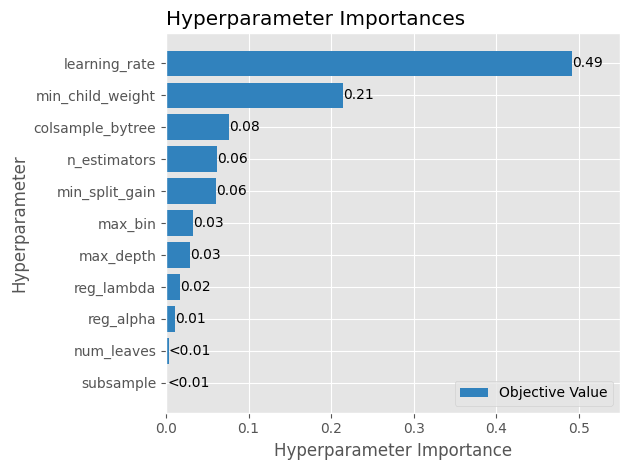

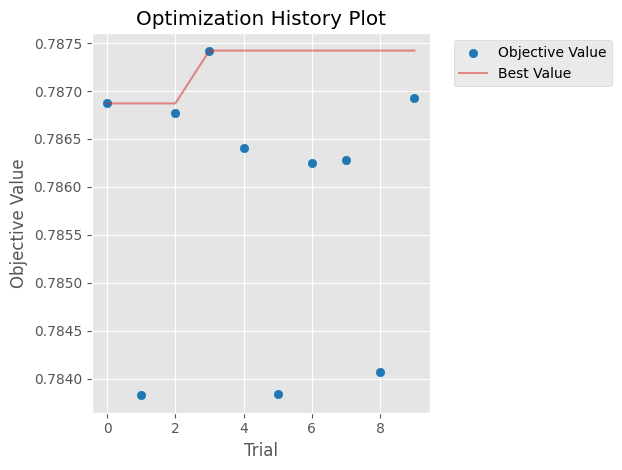

In [24]:
# Cell 4.5 — visualise Optuna results
print(f'Best AUC:    {study.best_value:.5f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k:<25} {v}')

# Which parameters influenced AUC the most?
optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()

# Did AUC keep improving or plateau?
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.show()

In [25]:
# import joblib

# # Save after study completes (or even mid-study in a new cell)
# joblib.dump(study, "/kaggle/working/optuna_study.pkl")

['/kaggle/working/optuna_study.pkl']

In [13]:
def run_final_lgbm(train_df, test_df, n_splits=5, params_override=None):
    """
    Final training run with target encoding inside CV loop.
    High-cardinality columns are encoded per fold to prevent leakage.
    params_override: if provided, uses these params instead of defaults.
                     used to inject Optuna's best parameters.
    """

    # Identify which high-card columns are actually present
    HIGH_CARD_COLS = [c for c in [
        'ORGANIZATION_TYPE', 'OCCUPATION_TYPE'
        # 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
        # 'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS',
        # 'WEEKDAY_APPR_PROCESS_START'
    ] if c in train_df.columns]

    feature_cols = [c for c in train_df.columns
                    if c not in ['TARGET', 'SK_ID_CURR']]

    # Keep as dataframes — needed for target encoding by column name
    X_df      = train_df[feature_cols].copy()
    y         = train_df['TARGET'].values
    X_test_df = test_df[feature_cols].copy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    oof_preds  = np.zeros(len(X_df))
    test_preds = np.zeros(len(X_test_df))
    feat_imp   = np.zeros(len(feature_cols))

     # ── Default params (used if no Optuna override provided) ─
    default_params = {
        'objective':         'binary',
        'metric':            'auc',
        'n_estimators':     1000,
        'learning_rate':    0.02,
        'num_leaves':       34,
        'max_depth':        8,
        'colsample_bytree': 0.9497036,
        'subsample':        0.8715623,
        'reg_alpha':        0.041545473,
        'reg_lambda':       0.0735294,
        'min_split_gain':   0.0222415,
        'min_child_weight': 39.3259775,
        'max_bin':          255,
        # 'scale_pos_weight':  (train_df['TARGET']==0).sum() /
        #                      (train_df['TARGET']==1).sum(),
        'device':            'gpu',
        'random_state':      SEED,
        'n_jobs':           -1,
        'verbose':          -1,        
    }

    # ── Use Optuna params if provided, otherwise use defaults ─
    if params_override is not None:
        lgb_params = params_override
        print('Using Optuna tuned parameters.')
    else:
        lgb_params = default_params
        print('Using default parameters.')

    fold_aucs = []
    print(f'Training with target encoding on: {HIGH_CARD_COLS}')
    print('=' * 50)

    for fold, (trn_idx, val_idx) in enumerate(skf.split(X_df, y), 1):

        X_trn = X_df.iloc[trn_idx].copy()
        X_val = X_df.iloc[val_idx].copy()
        X_tst = X_test_df.copy()
        y_trn = y[trn_idx]
        y_val = y[val_idx]

        # ── Target encoding — fit on training fold only ───────
        global_mean = y_trn.mean()
        smoothing   = 10   # pulls rare categories toward global mean

        for col in HIGH_CARD_COLS:
            if col not in X_trn.columns:
                continue

            # Compute stats from training fold only
            stats = (
                pd.DataFrame({'cat': X_trn[col], 'target': y_trn})
                .groupby('cat')['target']
                .agg(['mean', 'count'])
            )

            # Smoothed encoding:
            # large groups  → trust their own mean
            # small groups  → pulled toward global mean
            stats['encoded'] = (
                (stats['mean'] * stats['count'] + global_mean * smoothing) /
                (stats['count'] + smoothing)
            )
            encode_map = stats['encoded'].to_dict()

            # Apply to all three splits
            # fillna(global_mean) handles unseen categories in val/test
            X_trn[col] = X_trn[col].map(encode_map).fillna(global_mean)
            X_val[col] = X_val[col].map(encode_map).fillna(global_mean)
            X_tst[col] = X_tst[col].map(encode_map).fillna(global_mean)

        # ── Train ─────────────────────────────────────────────
        model = lgb.LGBMClassifier(**lgb_params)
        model.fit(
            X_trn.values, y_trn,
            eval_set=[(X_val.values, y_val)],
            callbacks=[
                lgb.early_stopping(200, verbose=False),
                lgb.log_evaluation(500)
            ]
        )

        oof_preds[val_idx]  = model.predict_proba(X_val.values)[:, 1]
        test_preds         += model.predict_proba(X_tst.values)[:, 1] / n_splits
        feat_imp           += model.feature_importances_ / n_splits

        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        fold_aucs.append(fold_auc)
        print(f'  Fold {fold}  AUC = {fold_auc:.5f}  '
              f'best_iter = {model.best_iteration_}')

    oof_auc = roc_auc_score(y, oof_preds)
    print(f'\n  Final OOF AUC = {oof_auc:.5f}')
    print(f'  Fold AUCs: {[round(a,5) for a in fold_aucs]}')
    print(f'  Std: {np.std(fold_aucs):.5f}')

    # Feature importances
    imp_df = pd.DataFrame({
        'feature':    feature_cols,
        'importance': feat_imp
    }).sort_values('importance', ascending=False)

    print(f'\nTop 15 features:')
    print(imp_df.head(15).to_string(index=False))

    return oof_preds, test_preds, oof_auc

In [ ]:
best = study.best_params

lgb_params_tuned = {
    'objective':         'binary',
    'metric':            'auc',
    'device':            'gpu',
    'random_state':      SEED,
    'n_jobs':           -1,
    'verbose':          -1,
    # 'scale_pos_weight':  (app_train['TARGET']==0).sum() /
    #                      (app_train['TARGET']==1).sum(),
    'n_estimators':      best['n_estimators'],
    'learning_rate':     best['learning_rate'],
    'num_leaves':        best['num_leaves'],
    'max_depth':         best['max_depth'],
    'min_child_weight':  best['min_child_weight'],
    'min_split_gain':    best['min_split_gain'],
    'colsample_bytree':  best['colsample_bytree'],
    'subsample':         best['subsample'],
    # 'subsample_freq':    1,
    'reg_alpha':         best['reg_alpha'],
    'reg_lambda':        best['reg_lambda'],
    'max_bin':           best['max_bin'],
}

oof_final, test_final, final_auc = run_final_lgbm(
    app_train_final, app_test_final,
    params_override=lgb_params_tuned
)

is_unbalance present: False
scale_pos_weight: 11.387150050352467
Using Optuna tuned parameters.
Training with target encoding on: ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE']
[500]	valid_0's auc: 0.783398
[1000]	valid_0's auc: 0.784413
  Fold 1  AUC = 0.78454  best_iter = 837
[500]	valid_0's auc: 0.792943
[1000]	valid_0's auc: 0.793176
  Fold 2  AUC = 0.79366  best_iter = 823
[500]	valid_0's auc: 0.785482
[1000]	valid_0's auc: 0.786387
  Fold 3  AUC = 0.78654  best_iter = 810
[500]	valid_0's auc: 0.78882
[1000]	valid_0's auc: 0.789149
  Fold 4  AUC = 0.78972  best_iter = 847
[500]	valid_0's auc: 0.78302
[1000]	valid_0's auc: 0.784037
  Fold 5  AUC = 0.78414  best_iter = 1074

  Final OOF AUC = 0.78759
  Fold AUCs: [np.float64(0.78454), np.float64(0.79366), np.float64(0.78654), np.float64(0.78972), np.float64(0.78414)]
  Std: 0.00357

Top 15 features:
                     feature  importance
        ANNUITY_CREDIT_RATIO      1358.6
      DAYS_LAST_PHONE_CHANGE      1079.6
                EX

In [16]:
# ── Generate submission ───────────────────────────────────────
submission = pd.DataFrame({
    'SK_ID_CURR': app_test['SK_ID_CURR'],
    'TARGET':     test_final
})

submission.to_csv('submission.csv', index=False)

print('Submission saved.')
print(f'Shape: {submission.shape}')
print(f'TARGET range: [{submission.TARGET.min():.4f}, {submission.TARGET.max():.4f}]')
print(f'TARGET mean:   {submission.TARGET.mean():.4f}  (train TARGET mean: {app_train.TARGET.mean():.4f})')
print('\nFirst 5 rows:')
print(submission.head())

# Sanity check: predicted mean should be close to train mean
# Large divergence = something wrong in feature engineering
diff = abs(submission.TARGET.mean() - app_train.TARGET.mean())
if diff > 0.02:
    print(f'\nWARNING: predicted mean ({submission.TARGET.mean():.4f}) differs from '
          f'train mean ({app_train.TARGET.mean():.4f}) by {diff:.4f}')
    print('Check for leakage or preprocessing inconsistencies between train and test.')
else:
    print(f'\nPredicted mean is within expected range. Ready to submit.')

Submission saved.
Shape: (48744, 2)
TARGET range: [0.0011, 0.7905]
TARGET mean:   0.0705  (train TARGET mean: 0.0807)

First 5 rows:
   SK_ID_CURR    TARGET
0      100001  0.025076
1      100005  0.133689
2      100013  0.043353
3      100028  0.034814
4      100038  0.154291

Predicted mean is within expected range. Ready to submit.


In [33]:
# print(f'OOF predicted mean:   {oof_final.mean():.4f}')
# print(f'Train TARGET mean:    {app_train["TARGET"].mean():.4f}')

OOF predicted mean:   0.3384
Train TARGET mean:    0.0807


Training single model for feature importance and SHAP...
Done.


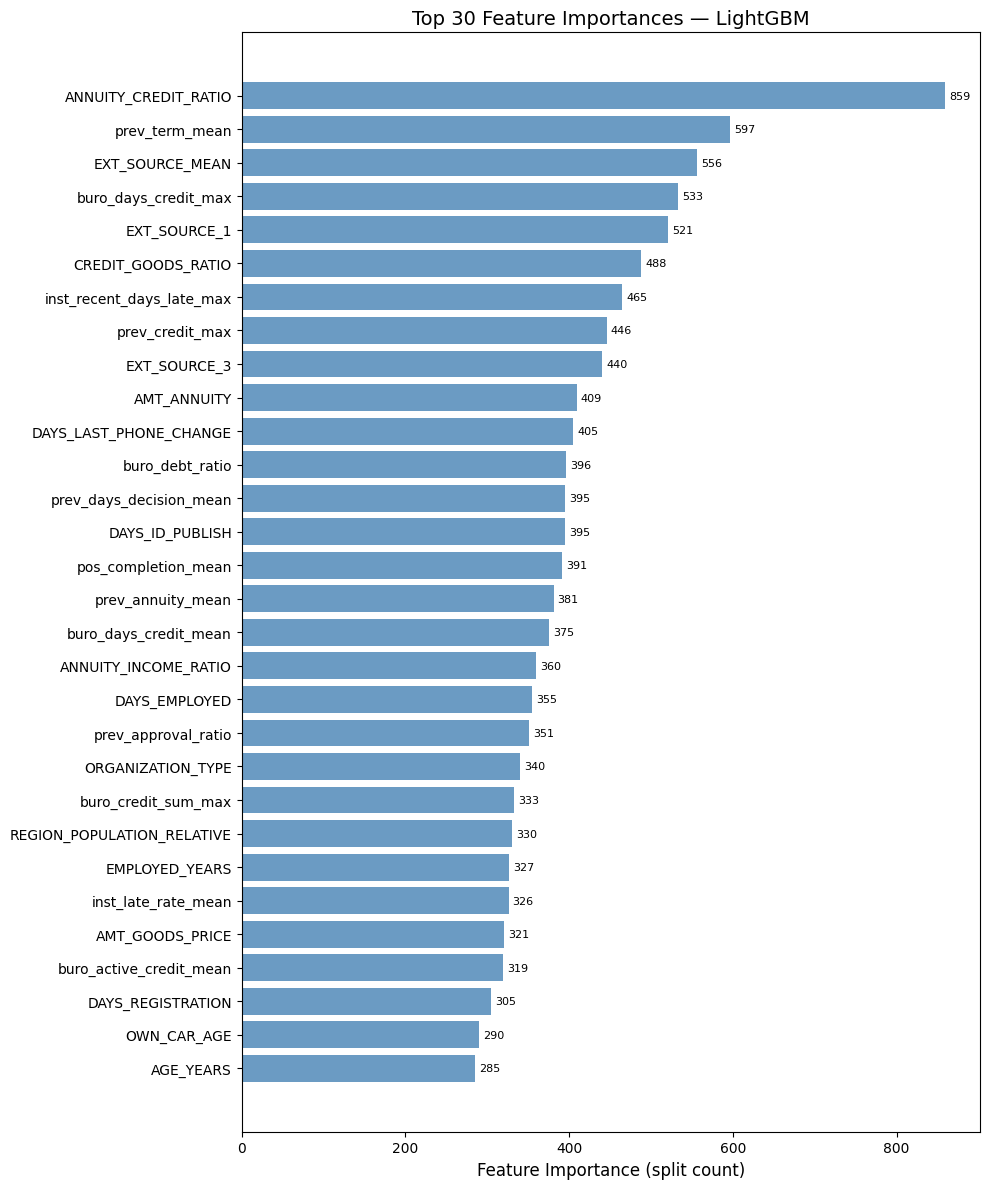


Top 15 features:
                  feature  importance
     ANNUITY_CREDIT_RATIO         859
           prev_term_mean         597
          EXT_SOURCE_MEAN         556
     buro_days_credit_max         533
             EXT_SOURCE_1         521
       CREDIT_GOODS_RATIO         488
inst_recent_days_late_max         465
          prev_credit_max         446
             EXT_SOURCE_3         440
              AMT_ANNUITY         409
   DAYS_LAST_PHONE_CHANGE         405
          buro_debt_ratio         396
  prev_days_decision_mean         395
          DAYS_ID_PUBLISH         395
      pos_completion_mean         391


In [17]:
# ── Feature Importance ────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

feature_cols = [c for c in app_train_final.columns
                if c not in ['TARGET', 'SK_ID_CURR']]

# ── Train one model on full data for importance + SHAP ────────
# We need a single trained model — run_final_lgbm trains 5 but
# does not return them. Train one model on full data here.
X_full = app_train_final[feature_cols].copy()
y_full = app_train_final['TARGET'].values

# Apply target encoding on full dataset
global_mean = y_full.mean()
smoothing   = 10
encode_maps = {}

for col in ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE']:
    if col in X_full.columns:
        stats = (
            pd.DataFrame({'cat': X_full[col], 'target': y_full})
            .groupby('cat')['target']
            .agg(['mean', 'count'])
        )
        stats['encoded'] = (
            (stats['mean'] * stats['count'] + global_mean * smoothing) /
            (stats['count'] + smoothing)
        )
        encode_maps[col] = stats['encoded'].to_dict()
        X_full[col] = X_full[col].map(encode_maps[col]).fillna(global_mean)

print('Training single model for feature importance and SHAP...')
single_model = lgb.LGBMClassifier(**lgb_params_tuned)
single_model.fit(X_full.values, y_full)
print('Done.')

# ── Plot 1: Top 30 feature importances ────────────────────────
imp_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': single_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 30
top30 = imp_df.head(30)

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(
    range(len(top30)),
    top30['importance'],
    color='steelblue',
    alpha=0.8
)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['feature'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (split count)', fontsize=12)
ax.set_title('Top 30 Feature Importances — LightGBM', fontsize=14)

# Add value labels
for bar, val in zip(bars, top30['importance']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 15 features:')
print(imp_df.head(15).to_string(index=False))

Computing SHAP values on 2000 sample rows...
Done.

Plot 1: Beeswarm (importance + direction)


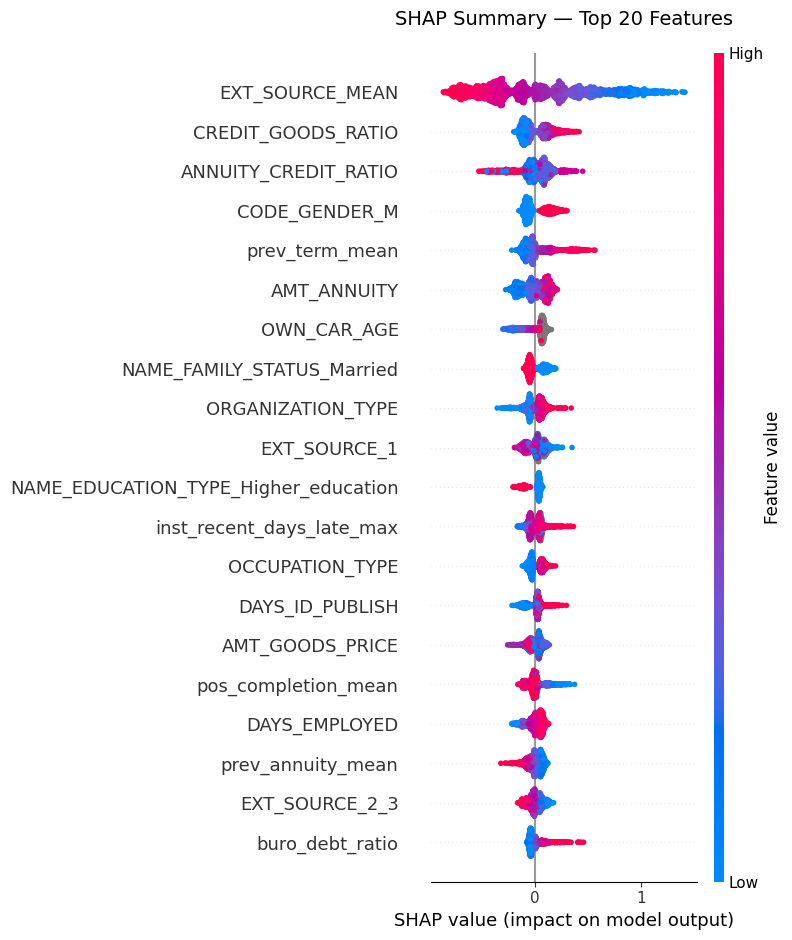


Plot 2: Mean absolute SHAP values


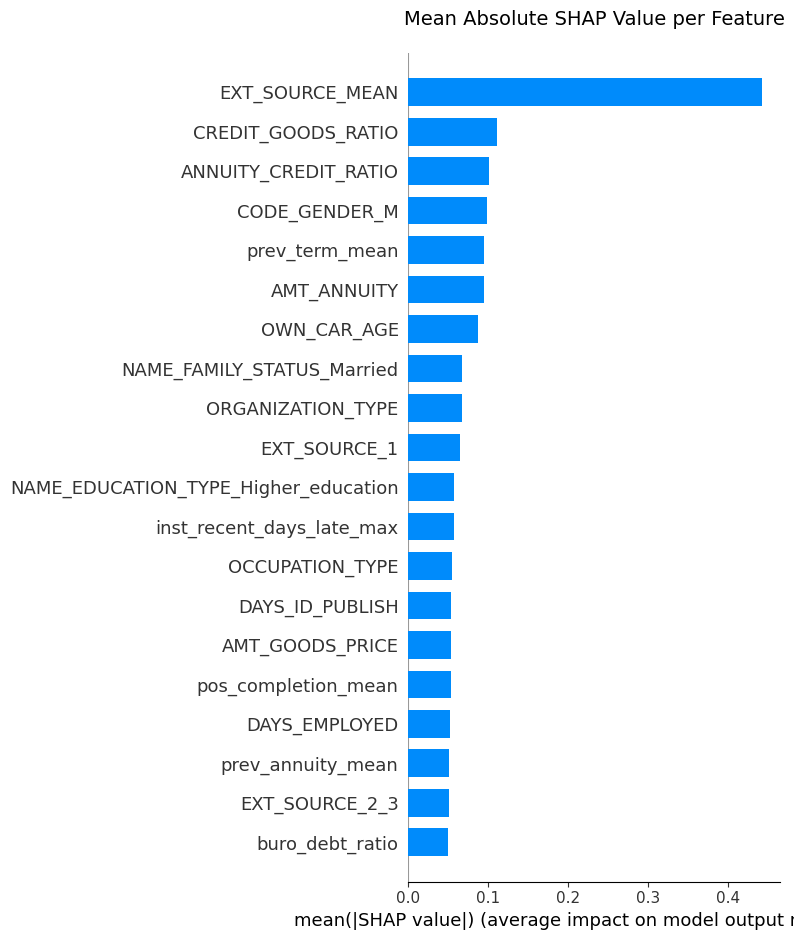


Plot 3: Waterfall — random applicant with mixed signals
Selected applicant index 1280 from 1767 mixed-signal candidates


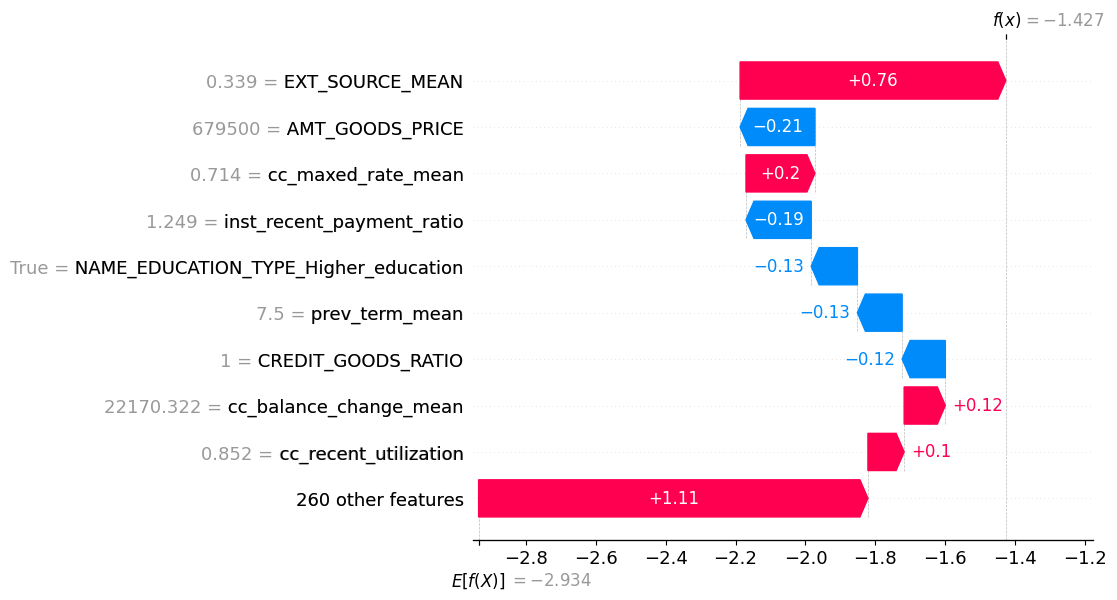

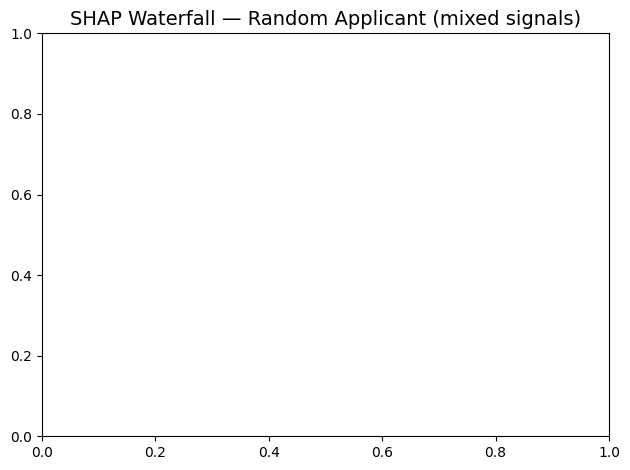


Predicted default probability: 0.2198
Positive SHAP features (pushing toward default):     128
Negative SHAP features (pushing toward non-default): 100

── SHAP Feature Ranking (mean absolute value) ───────
                             feature  mean_abs_shap
                     EXT_SOURCE_MEAN       0.443195
                  CREDIT_GOODS_RATIO       0.110491
                ANNUITY_CREDIT_RATIO       0.100481
                       CODE_GENDER_M       0.098403
                      prev_term_mean       0.095020
                         AMT_ANNUITY       0.094722
                         OWN_CAR_AGE       0.087055
          NAME_FAMILY_STATUS_Married       0.067561
                   ORGANIZATION_TYPE       0.067383
                        EXT_SOURCE_1       0.064407
NAME_EDUCATION_TYPE_Higher_education       0.056949
           inst_recent_days_late_max       0.056710
                     OCCUPATION_TYPE       0.055269
                     DAYS_ID_PUBLISH       0.053638
            

In [ ]:
# ── SHAP Analysis ─────────────────────────────────────────────
!pip install shap -q
import shap

# ── Compute SHAP values on a sample ──────────────────────────
# Full dataset is slow — 2000 rows is enough for reliable analysis
np.random.seed(SEED)
sample_size = 2000
sample_idx  = np.random.choice(len(X_full), size=sample_size, replace=False)
X_sample    = X_full.values[sample_idx]

print('Computing SHAP values on 2000 sample rows...')
explainer   = shap.TreeExplainer(single_model)
shap_values = explainer.shap_values(X_sample)

# For binary classification LightGBM returns a list of 2 arrays
# shap_values[1] = values for class 1 (default) — this is what we want
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print('Done.')

# ── Plot 1: Beeswarm summary plot ─────────────────────────────
# Most important SHAP plot — shows both importance AND direction
print('\nPlot 1: Beeswarm (importance + direction)')
plt.figure(figsize=(12, 10))
shap.summary_plot(
    sv,
    X_sample,
    feature_names=feature_cols,
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Top 20 Features', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Bar plot (mean absolute SHAP) ─────────────────────
# Simpler — just ranks features by average impact
print('\nPlot 2: Mean absolute SHAP values')
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv,
    X_sample,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Mean Absolute SHAP Value per Feature', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Waterfall for a random applicant ──────────────────
# Pick a random person who has BOTH positive and negative SHAP values
# so the plot shows features pushing in both directions
print('\nPlot 3: Waterfall — random applicant with mixed signals')

np.random.seed(SEED)

# Find applicants who have both positive and negative SHAP values
# meaning the model is genuinely weighing competing signals for them
mixed_mask = (
    (sv.max(axis=1) > 0.1) &    # at least one feature pushing toward default
    (sv.min(axis=1) < -0.1)     # at least one feature pushing toward non-default
)
mixed_indices = np.where(mixed_mask)[0]

if len(mixed_indices) == 0:
    # Fallback — just pick any random index
    random_idx = np.random.randint(0, len(X_sample))
    print('No mixed-signal applicant found — using random index')
else:
    # Pick one randomly from the mixed-signal pool
    random_idx = np.random.choice(mixed_indices)
    print(f'Selected applicant index {random_idx} from {len(mixed_indices)} '
          f'mixed-signal candidates')

# Get base value
base_val = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, list)
    else explainer.expected_value
)

shap.waterfall_plot(
    shap.Explanation(
        values        = sv[random_idx],
        base_values   = base_val,
        data          = X_sample[random_idx],
        feature_names = feature_cols
    )
)
plt.title('SHAP Waterfall — Random Applicant (mixed signals)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_waterfall_random.png', dpi=150, bbox_inches='tight')
plt.show()

# Print what the model predicted for this person
oof_sample = oof_final[sample_idx]
print(f'\nPredicted default probability: {oof_sample[random_idx]:.4f}')
print(f'Positive SHAP features (pushing toward default):     '
      f'{(sv[random_idx] > 0).sum()}')
print(f'Negative SHAP features (pushing toward non-default): '
      f'{(sv[random_idx] < 0).sum()}')

# ── Summary statistics ────────────────────────────────────────
print('\n── SHAP Feature Ranking (mean absolute value) ───────')
shap_importance = pd.DataFrame({
    'feature':          feature_cols,
    'mean_abs_shap':    np.abs(sv).mean(0)
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance.head(20).to_string(index=False))